# Esercizio 06 — Modello di Ising 1D

In questo esercizio si studia il modello di Ising monodimensionale ferromagnetico con condizioni periodiche. L'obiettivo è simulare il sistema nell'ensemble canonico usando due algoritmi Monte Carlo, Metropolis e Gibbs sampling, e confrontare le stime numeriche con le curve analitiche esatte.

Le grandezze richieste sono l'energia interna per spin $U/N$, il calore specifico $C$, la suscettività magnetica $\chi$ e la magnetizzazione per spin $M/N$. Le prime tre sono calcolate a campo nullo, mentre la magnetizzazione è calcolata a campo esterno $h=0.02$.


## Modello fisico

Il sistema è formato da $N=50$ spin classici

$$
s_i = \pm 1,
$$

con interazione ferromagnetica tra primi vicini. L'Hamiltoniana è

$$
H = -J\sum_{i=1}^{N}s_i s_{i+1}
-\frac{h}{2}\sum_{i=1}^{N}(s_i+s_{i+1}),
$$

con condizioni periodiche

$$
s_{N+1}=s_1.
$$

Nel seguito si usa $J=1$ e $k_B=1$, quindi $\beta=1/T$.

Nell'ensemble canonico una configurazione $\{s_i\}$ ha peso di Boltzmann

$$
p(\{s_i\}) = \frac{e^{-\beta H(\{s_i\})}}{Z}.
$$

In una dimensione non c'è transizione di fase ferromagnetica a temperatura finita, ma per una catena finita e a bassa temperatura il sistema può comunque mostrare lunghe configurazioni ordinate e forti fluttuazioni della magnetizzazione.


## Osservabili misurate

Le osservabili sono state stimate tramite data blocking. Ogni file di output contiene, per ogni blocco, tre informazioni principali: la stima del blocco, la media progressiva fino a quel blocco e l'errore statistico progressivo.

Per $h=0$ sono state misurate:

$$
\frac{U}{N}=\frac{\langle H\rangle}{N},
$$

$$
C=\frac{\beta^2}{N}\left(\langle H^2\rangle-\langle H\rangle^2\right),
$$

$$
\chi=\frac{\beta}{N}\left\langle \left(\sum_i s_i\right)^2\right\rangle.
$$

Per $h=0.02$ è stata misurata la magnetizzazione per spin:

$$
\frac{M}{N}=\frac{1}{N}\left\langle \sum_i s_i\right\rangle.
$$

## Metropolis e Gibbs sampling

Nel codice originale era già presente l'algoritmo di Metropolis. Per il modello di Ising, una mossa elementare Metropolis consiste nello scegliere uno spin $s_i$, proporre il flip

$$
s_i \rightarrow -s_i,
$$

e accettarlo con probabilità

$$
A = \min\left(1,e^{-\beta\Delta E}\right).
$$

Un Monte Carlo step completo del nostro codice non coincide però con una sola mossa elementare. La funzione `step()` esegue $N$ tentativi di aggiornamento, dove $N$ è il numero di spin:

```cpp
for(int i=0; i<_npart; i++)
  this->move(int(_rnd.Rannyu()*_npart));
```

Il Gibbs sampling è diverso: non propone un flip da accettare o rigettare, ma riscrive direttamente il valore dello spin secondo la probabilità condizionata corretta, tenendo fissi tutti gli altri spin. In questo caso, siccome le interazioni sono solo tra primi vicini, è sufficiente fissare i due spin adiacenti.

I soli termini dell'energia che dipendono da $s_i$ sono

$$
E_i(s_i)=-J s_i(s_{i-1}+s_{i+1})-h s_i.
$$

Definendo

$$
h_{\mathrm{eff}}=J(s_{i-1}+s_{i+1})+h,
$$

si ottiene

$$
E_i(s_i)=-s_i h_{\mathrm{eff}}.
$$

Quindi la probabilità di assegnare allo spin il valore $+1$ è

$$
P(s_i=+1)=
\frac{e^{-\beta E_i(+1)}}
{e^{-\beta E_i(+1)}+e^{-\beta E_i(-1)}}
=
\frac{1}{1+e^{-2\beta h_{\mathrm{eff}}}}.
$$

Questa è la formula implementata nel ramo Gibbs. Poiché lo spin viene estratto direttamente dalla distribuzione condizionata, ogni mossa Gibbs è formalmente accettata: per questo l'accettanza stampata dal codice vale $1$.


## Implementazione C++

La simulazione è stata organizzata in modo da non modificare manualmente il codice per ogni temperatura. Il programma principale riceve da terminale il nome della run:

```cpp
string run_name = argv[1];
System SYS(run_name);
```

La classe `System` usa questo nome per leggere input e scrivere output nelle cartelle corrispondenti:

```cpp
System :: System(string run_name){
  _run_name = run_name;
  _input_dir = "../INPUT/runs/" + run_name;
  _output_dir = "../OUTPUT/" + run_name;
}

string System :: input_path(string filename){
  return _input_dir + "/" + filename;
}

string System :: output_path(string filename){
  return _output_dir + "/" + filename;
}
```

Per esempio, la run `metro_h0_T1.00` legge da `INPUT/runs/metro_h0_T1.00/` e scrive in `OUTPUT/metro_h0_T1.00/`.

Per eseguire la scansione in temperatura è stato usato uno script Bash, `run_temperature_scan.sh`. Lo script non modifica la simulazione, automatizza solo le operazioni che altrimenti andrebbero ripetute a mano. Per ogni temperatura e per ciascuna delle quattro famiglie di run (`metro_h0`, `gibbs_h0`, `metro_h002`, `gibbs_h002`), lo script crea le cartelle di input e output, copia i file comuni del generatore random, copia il template di input corretto e cambia solo la riga `TEMP`.

In questo modo il codice C++ rimane unico. Cambiano soltanto i file di input delle singole run, mentre il programma viene sempre lanciato nella forma

```bash
./simulator.exe nome_run
```

dove `nome_run` identifica automaticamente la cartella da cui leggere l'input e quella in cui salvare i risultati.


### Aggiornamento degli spin

Nel metodo `System::step()` un Monte Carlo step corrisponde a $N$ tentativi di aggiornamento di spin scelti casualmente:

```cpp
void System :: step(){
  if(_sim_type == 0) this->Verlet();
  else for(int i=0; i<_npart; i++) this->move(int(_rnd.Rannyu()*_npart));
  _nattempts += _npart;
}
```

Con $N=50$, quindi, un MC step contiene 50 aggiornamenti elementari di singolo spin. Poiché lo spin da aggiornare viene scelto casualmente a ogni tentativo, non è garantito che in uno step tutti gli spin vengano visitati esattamente una volta; alcuni possono essere scelti più volte e altri nessuna. Tuttavia, in media, un MC step corrisponde a uno sweep della catena, cioè a un tentativo di aggiornamento per spin.

Questa definizione vale sia per Metropolis sia per Gibbs. La differenza tra i due algoritmi non è nel numero di tentativi per step, ma nella regola con cui viene aggiornato lo spin scelto.

Nel metodo `System::move()` il caso `_sim_type == 2` corrisponde a Metropolis, mentre `_sim_type == 3` corrisponde al Gibbs sampling:

```cpp
if(_sim_type == 3){
  double s_left  = double(_particle(this->pbc(i-1)).getspin());
  double s_right = double(_particle(this->pbc(i+1)).getspin());

  double h_eff = _J * (s_left + s_right) + _H;
  double p_up = 1.0 / (1.0 + exp(-2.0 * _beta * h_eff));

  if(_rnd.Rannyu() < p_up) _particle(i).setspin(1);
  else                     _particle(i).setspin(-1);

  _naccepted++;
}
```

La funzione `pbc()` sugli indici garantisce le condizioni periodiche: per esempio, il vicino sinistro dello spin $0$ è lo spin $N-1$.


### Misura delle osservabili

L'energia interna viene misurata come energia per spin:

```cpp
for (int i=0; i<_npart; i++){
  s_i = double(_particle(i).getspin());
  s_j = double(_particle(this->pbc(i+1)).getspin());
  tenergy_temp += - _J * s_i * s_j - 0.5 * _H * (s_i + s_j);
}
tenergy_temp /= double(_npart);
```

Per il calore specifico, invece, in `measure()` viene accumulato il termine con $H^2$ usando l'energia totale:

```cpp
energy_total += - _J * s_i * s_j - 0.5 * _H * (s_i + s_j);
_measurement(_index_cv) = _beta * _beta * energy_total * energy_total / double(_npart);
```

Poi in `averages()` viene sottratto il termine con $\langle H\rangle^2$:

```cpp
if (_measure_cv && _measure_tenergy) {
  _average(_index_cv) -= _beta * _beta * double(_npart)
                         * pow(_average(_index_tenergy), 2);
}
```

Questo passaggio è necessario per ottenere, blocco per blocco,

$$
C=\frac{\beta^2}{N}\left(\langle H^2\rangle-\langle H\rangle^2\right).
$$

La suscettività viene misurata a campo nullo come

```cpp
chi_temp = chi_temp*chi_temp;
_measurement(_index_chi) = (1 / _temp) * chi_temp / double(_npart);
```

mentre la magnetizzazione è salvata direttamente per spin:

```cpp
_measurement(_index_magnet) = magnetization / double(_npart);
```

Nella produzione finale ogni punto in temperatura è stato ottenuto con 50 blocchi da 20000 MC step ciascuno. Per costruire i grafici, il notebook legge l'ultima riga di ogni file di output, cioè la media progressiva e l'errore progressivo dopo l'ultimo blocco. Prima della fase di misura viene eseguita una breve equilibrazione iniziale di 10000 mosse elementari di singolo spin, corrispondenti a circa 200 sweep per una catena di 50 spin. Dopo questa fase i contatori di accettazione vengono azzerati e inizia la produzione statistica con data blocking.

## Lettura dei dati

Il notebook legge solo le cartelle prodotte dalla scansione finale, cioè quelle con nomi del tipo:

```text
metro_h0_T0.50
metro_h0_T0.60
...
gibbs_h002_T2.00
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path(".").resolve()
OUTPUT = ROOT / "Ex_06/OUTPUT"

TEMPERATURES = np.round(np.linspace(0.5, 2.0, 16), 2)
N_SPINS = 50
J = 1.0
H_MAG = 0.02

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 12

In [2]:
def read_last_progressive_value(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File non trovato: {path}")

    data = np.loadtxt(path, comments="#")

    progressive_average = data[-1, 2]
    progressive_error = data[-1, 3]

    return progressive_average, progressive_error


def load_observable(run_prefix, filename):
    values = []
    errors = []

    for T in TEMPERATURES:
        run_name = f"{run_prefix}_T{T:.2f}"
        path = OUTPUT / run_name / filename

        value, error = read_last_progressive_value(path)

        values.append(value)
        errors.append(error)

    return np.array(values), np.array(errors)

In [3]:
# Dati numerici a h = 0
U_metro, dU_metro = load_observable("metro_h0", "total_energy.dat")
U_gibbs, dU_gibbs = load_observable("gibbs_h0", "total_energy.dat")

C_metro, dC_metro = load_observable("metro_h0", "specific_heat.dat")
C_gibbs, dC_gibbs = load_observable("gibbs_h0", "specific_heat.dat")

X_metro, dX_metro = load_observable("metro_h0", "susceptibility.dat")
X_gibbs, dX_gibbs = load_observable("gibbs_h0", "susceptibility.dat")

# Dati numerici a h = 0.02
M_metro, dM_metro = load_observable("metro_h002", "magnetization.dat")
M_gibbs, dM_gibbs = load_observable("gibbs_h002", "magnetization.dat")

In [4]:
def exact_energy(T, N=N_SPINS, J=J):
    beta = 1.0 / T
    th = np.tanh(J / T)
    thN = th**N
    ch = 1.0 / th
    return -J * (th + ch * thN) / (1.0 + thN)


def exact_heat_capacity(T, N=N_SPINS, J=J):
    beta = 1.0 / T
    th = np.tanh(J / T)
    thN = th**N
    ch = 1.0 / th
    return (beta * J)**2 * (
        ((1.0 + thN + (N - 1.0) * th**2 + (N - 1.0) * ch**2 * thN) / (1.0 + thN))
        - N * ((th + ch * thN) / (1.0 + thN))**2
    )


def exact_susceptibility(T, N=N_SPINS, J=J):
    beta = 1.0 / T
    th = np.tanh(J / T)
    thN = th**N
    return beta * np.exp(2.0 * beta * J) * (1.0 - thN) / (1.0 + thN)


def exact_magnetization(T, N=N_SPINS, J=J, h=H_MAG):
    beta = 1.0 / T
    root = np.sqrt(np.exp(2.0 * beta * J) * np.cosh(beta * h)**2 - 2.0 * np.sinh(2.0 * beta * J))
    lambda_1 = np.exp(beta * J) * np.cosh(beta * h) + root
    lambda_2 = np.exp(beta * J) * np.cosh(beta * h) - root
    Z = lambda_1**N + lambda_2**N

    numerator = np.exp(beta * J) * np.sinh(beta * h) * (
        lambda_1**(N - 1) * (1.0 + np.exp(beta * J) * np.cosh(beta * h) / root)
        + lambda_2**(N - 1) * (1.0 - np.exp(beta * J) * np.cosh(beta * h) / root)
    )

    return numerator / Z

T_exact = np.linspace(0.5, 2.0, 400)

## Energia interna per spin

A campo nullo l'energia per spin deve crescere con la temperatura: a bassa temperatura il sistema è quasi ferromagneticamente ordinato e $U/N$ è vicino a $-1$, mentre aumentando $T$ gli spin diventano meno correlati e l'energia diventa meno negativa.


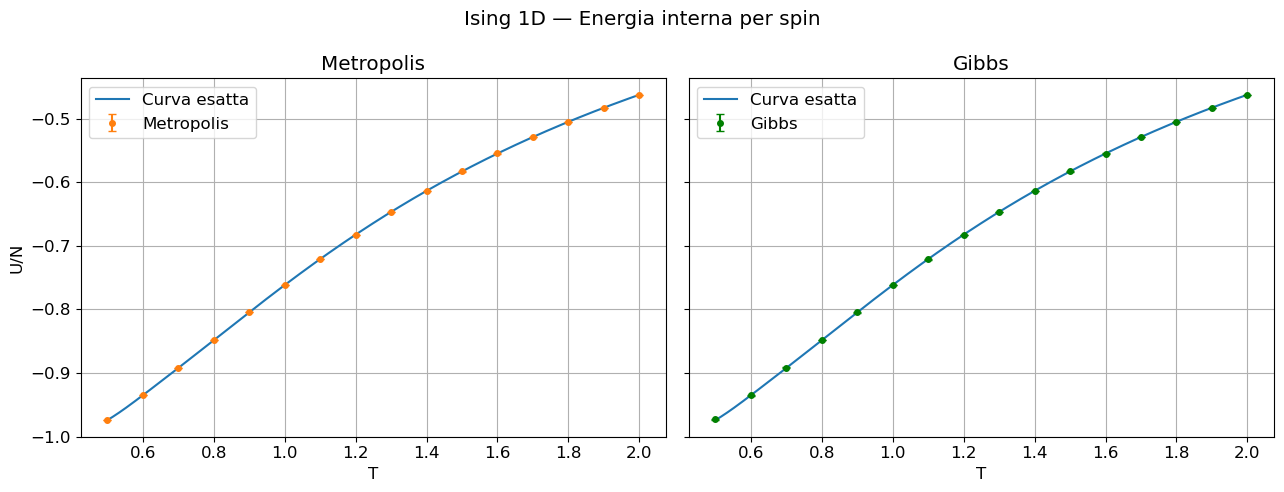

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# Metropolis
axes[0].plot(T_exact, exact_energy(T_exact), label="Curva esatta")
axes[0].errorbar(
    TEMPERATURES, U_metro, yerr=dU_metro,
    fmt="o", markersize=4, capsize=3,
    label="Metropolis"
)
axes[0].set_xlabel("T")
axes[0].set_ylabel("U/N")
axes[0].set_title("Metropolis")
axes[0].legend()

# Gibbs
axes[1].plot(T_exact, exact_energy(T_exact), label="Curva esatta")
axes[1].errorbar(
    TEMPERATURES, U_gibbs, yerr=dU_gibbs,
    fmt="o", markersize=4, capsize=3,
    label="Gibbs", color="green"
)
axes[1].set_xlabel("T")
axes[1].set_title("Gibbs")
axes[1].legend()

fig.suptitle("Ising 1D — Energia interna per spin")
plt.tight_layout()
plt.show()

Le due simulazioni seguono la curva analitica. Metropolis e Gibbs forniscono stime compatibili tra loro entro le incertezze statistiche. Questo è un controllo importante: i due algoritmi aggiornano gli spin in modo diverso, ma devono riprodurre la stessa distribuzione canonica.


## Calore specifico

Il calore specifico misura le fluttuazioni dell'energia. Per questo motivo è più delicato dell'energia media: non basta stimare $\langle H\rangle$, ma bisogna stimare correttamente anche $\langle H^2\rangle$.


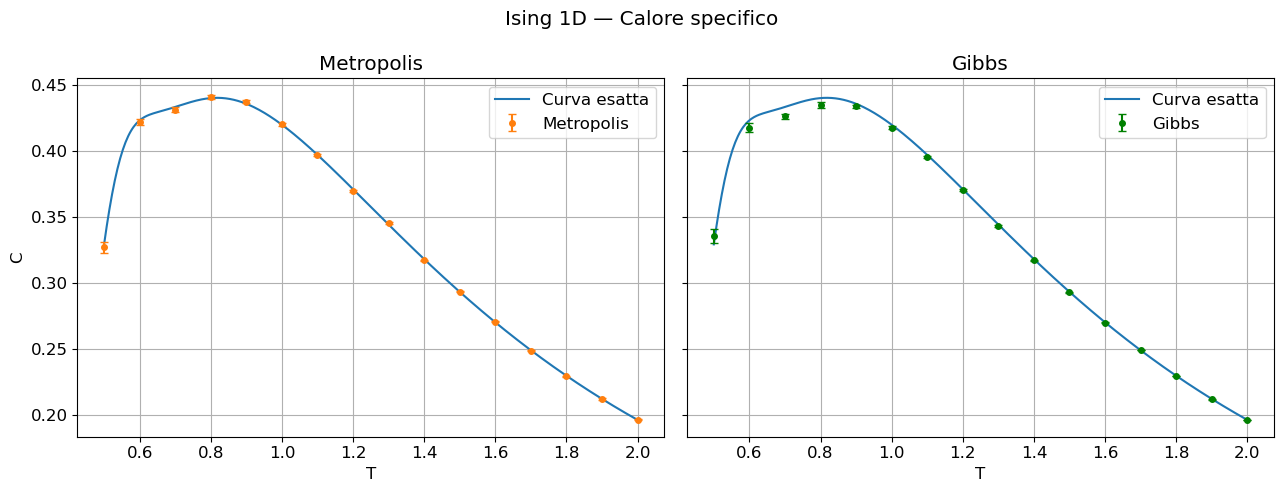

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# Metropolis
axes[0].plot(T_exact, exact_heat_capacity(T_exact), label="Curva esatta")
axes[0].errorbar(
    TEMPERATURES, C_metro, yerr=dC_metro,
    fmt="o", markersize=4, capsize=3,
    label="Metropolis"
)
axes[0].set_xlabel("T")
axes[0].set_ylabel("C")
axes[0].set_title("Metropolis")
axes[0].legend()

# Gibbs
axes[1].plot(T_exact, exact_heat_capacity(T_exact), label="Curva esatta")
axes[1].errorbar(
    TEMPERATURES, C_gibbs, yerr=dC_gibbs,
    fmt="o", markersize=4, capsize=3,
    label="Gibbs", color="green"
)
axes[1].set_xlabel("T")
axes[1].set_title("Gibbs")
axes[1].legend()

fig.suptitle("Ising 1D — Calore specifico")
plt.tight_layout()
plt.show()

Anche per il calore specifico si osserva un buon accordo con la soluzione esatta. Gli scostamenti locali sono più visibili che nel grafico dell'energia perché $C$ dipende da una varianza, quindi è statisticamente più sensibile alle fluttuazioni dei blocchi.


## Suscettività magnetica

La suscettività a campo nullo è legata alle fluttuazioni della magnetizzazione totale:

$$
\chi=\frac{\beta}{N}\langle M^2\rangle,
\qquad
M=\sum_i s_i.
$$

A basse temperature la catena tende a essere molto ordinata e la magnetizzazione totale può assumere valori grandi in modulo; di conseguenza la suscettività è elevata.


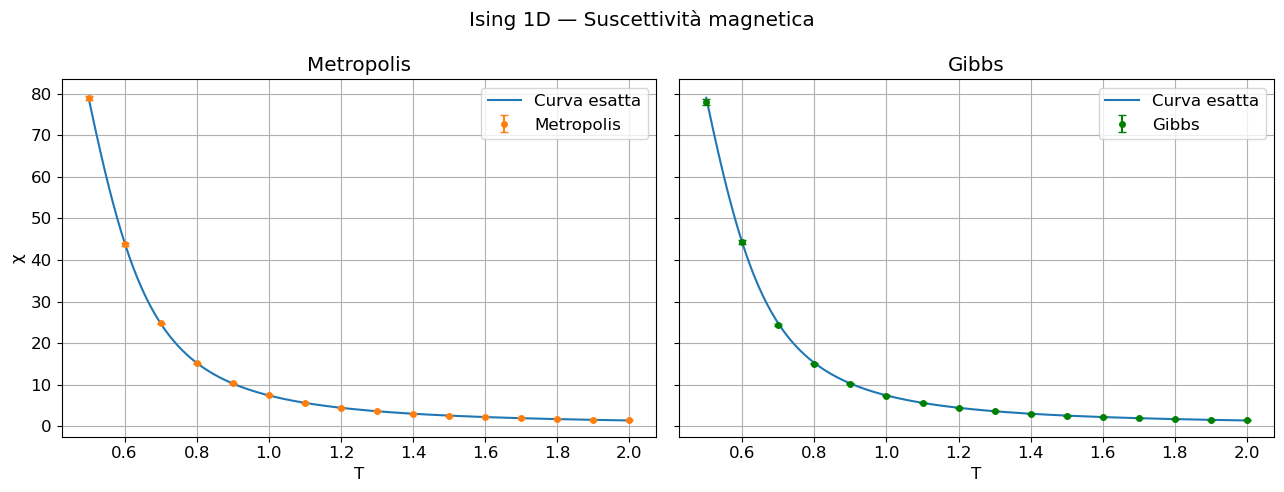

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# Metropolis
axes[0].plot(T_exact, exact_susceptibility(T_exact), label="Curva esatta")
axes[0].errorbar(
    TEMPERATURES, X_metro, yerr=dX_metro,
    fmt="o", markersize=4, capsize=3,
    label="Metropolis"
)
axes[0].set_xlabel("T")
axes[0].set_ylabel("χ")
axes[0].set_title("Metropolis")
axes[0].legend()

# Gibbs
axes[1].plot(T_exact, exact_susceptibility(T_exact), label="Curva esatta")
axes[1].errorbar(
    TEMPERATURES, X_gibbs, yerr=dX_gibbs,
    fmt="o", markersize=4, capsize=3,
    label="Gibbs", color="green"
)
axes[1].set_xlabel("T")
axes[1].set_title("Gibbs")
axes[1].legend()

fig.suptitle("Ising 1D — Suscettività magnetica")
plt.tight_layout()
plt.show()

Metropolis e Gibbs riproducono bene l'andamento della curva teorica. La suscettività è grande a bassa temperatura, dove la catena tende a rimanere in configurazioni quasi completamente ordinate e quindi la magnetizzazione totale ha modulo elevato. Aumentando la temperatura, l'ordine magnetico viene progressivamente distrutto e $\chi$ diminuisce rapidamente. 


## Magnetizzazione con campo esterno

A campo nullo la magnetizzazione media è nulla per simmetria: le configurazioni con magnetizzazione positiva e negativa hanno lo stesso peso. Per osservare una magnetizzazione media non nulla si introduce quindi un piccolo campo esterno positivo, qui $h=0.02$.


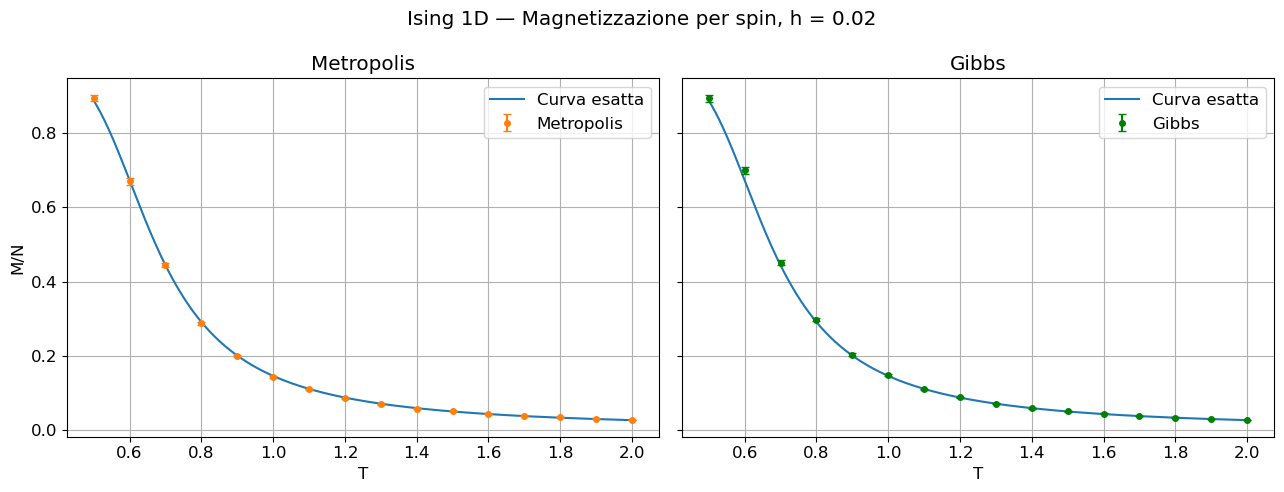

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# Metropolis
axes[0].plot(T_exact, exact_magnetization(T_exact), label="Curva esatta")
axes[0].errorbar(
    TEMPERATURES, M_metro, yerr=dM_metro,
    fmt="o", markersize=4, capsize=3,
    label="Metropolis"
)
axes[0].set_xlabel("T")
axes[0].set_ylabel("M/N")
axes[0].set_title("Metropolis")
axes[0].legend()

# Gibbs
axes[1].plot(T_exact, exact_magnetization(T_exact), label="Curva esatta")
axes[1].errorbar(
    TEMPERATURES, M_gibbs, yerr=dM_gibbs,
    fmt="o", markersize=4, capsize=3,
    label="Gibbs", color="green"
)
axes[1].set_xlabel("T")
axes[1].set_title("Gibbs")
axes[1].legend()

fig.suptitle("Ising 1D — Magnetizzazione per spin, h = 0.02")
plt.tight_layout()
plt.show()

La magnetizzazione diminuisce al crescere della temperatura: il campo esterno favorisce gli spin positivi, ma l'agitazione termica rende l'allineamento progressivamente meno efficace. Anche in questo caso Metropolis e Gibbs risultano compatibili e seguono la curva analitica.


## Conclusioni

Le simulazioni Monte Carlo del modello di Ising 1D riproducono correttamente le curve analitiche per tutte le osservabili richieste. Metropolis e Gibbs sampling danno risultati compatibili, pur usando meccanismi di aggiornamento diversi.

Dal punto di vista implementativo, le modifiche principali sono state l'aggiunta del Gibbs sampling, la misura di $C$, $\chi$ e $M/N$, e l'organizzazione delle run tramite nomi del tipo `metro_h0_T1.00`. Questo ha permesso di eseguire automaticamente la scansione in temperatura senza creare a mano tutti gli input.

Le differenze statistiche più evidenti compaiono nelle grandezze legate alle fluttuazioni, soprattutto $C$ e $\chi$, perché richiedono una buona stima di momenti quadratici. L'accordo globale con la teoria mostra però che la simulazione nell'ensemble canonico è stata implementata correttamente.
